# Ovarian cancer data analysis
Train steamboat model on HGSC data.

In [2]:
import os
import scanpy as sc
import squidpy as sq
import numpy as np
import scipy as sp
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import json

c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\spatialdata\_core\query\relational_query.py:530: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\spatialdata\_core\query\relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = parti

In [3]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['font.family'] = 'arial'

pltkw = dict(bbox_inches='tight', transparent=True)

In [4]:
import sys
sys.path.append("..")
import steamboat as sf
import steamboat.tools
import torch
device = 'cuda'

In [5]:
import importlib
importlib.reload(steamboat.tools)

<module 'steamboat.tools' from 'c:\\Files\\projects\\Steamboat\\revised\\..\\steamboat\\tools.py'>

In [6]:
# https://www.nature.com/articles/s41590-024-01943-5

## Load data

In [7]:
regenerate = False

h5ad_file = "../../../data/HGSC/ST_Discovery_so.h5ad"
if (not os.path.exists(h5ad_file)) or regenerate:
    adata = sc.read_mtx("G:/data/HGSC/Csv/ST_Discovery_so_counts.mtx").T
    metadata = pd.read_csv("G:/data/HGSC/Csv/ST_Discovery_so_metadata.csv", index_col=0)
    features = pd.read_csv("G:/data/HGSC/Csv/ST_Discovery_so_features.txt", index_col=0, header=None)
    features.index = features.index.str.strip() # remove trailing white space in gene names
    features.index.name = 'gene_symbol'
    adata.obs = metadata
    adata.var = features
    adata.obsm['spatial'] = adata.obs[['x', 'y']].to_numpy()
    adata.write_h5ad("G:/data/HGSC/h5ad/ST_Discovery_so.h5ad")
else:
    adata = sc.read_h5ad(h5ad_file)

In [8]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,samples,patients,sites_binary,cell.types,cell.subtypes,x,y
SMI_T10_F001_c1017,SMI,848,357,SMI_T10_F001,HGSC1,Adnexa,Malignant,Malignant,1493.3500,3151.233
SMI_T10_F001_c102,SMI,731,319,SMI_T10_F001,HGSC1,Adnexa,Malignant,Malignant,2623.2000,3607.450
SMI_T10_F001_c1062,SMI,236,155,SMI_T10_F001,HGSC1,Adnexa,Malignant,Malignant,850.5670,3143.833
SMI_T10_F001_c1064,SMI,609,300,SMI_T10_F001,HGSC1,Adnexa,Malignant,Malignant,3222.7300,3152.586
SMI_T10_F001_c1075,SMI,310,174,SMI_T10_F001,HGSC1,Adnexa,Malignant,Malignant,78.0125,3179.012
...,...,...,...,...,...,...,...,...,...,...
SMI_T14_F020_c5758,SMI,100,63,SMI_T14_F020,HGSC89,Omentum,TNK.cell,CD4.T.cell.DN,5170.4400,431.900
SMI_T14_F020_c734,SMI,141,88,SMI_T14_F020,HGSC89,Omentum,Fibroblast,Fibroblast,768.7000,3188.400
SMI_T14_F020_c875,SMI,78,60,SMI_T14_F020,HGSC89,Omentum,Malignant,Malignant,42.5833,3070.350
SMI_T14_F020_c3288,SMI,104,58,SMI_T14_F020,HGSC89,Omentum,Fibroblast,Fibroblast,48.9889,1751.740


In [9]:
TNK_info = adata.obs[adata.obs['cell.types'] == 'Monocyte']
TNK_info['cell.subtypes'].value_counts()

cell.subtypes
Monocyte            35182
B.cell                  0
B.cell_LC               0
Treg                    0
T.cell.DP_LC            0
T.cell.DP               0
T.B.cell_LC             0
T.B.cell                0
NK.cell_LC              0
NK.cell                 0
Monocyte_LC             0
Mast.cell_LC            0
Mast.cell               0
Malignant_LC            0
Malignant               0
Fibroblast_LC           0
Fibroblast              0
Endothelial_LC          0
Endothelial             0
CD8.T.cell_LC           0
CD8.T.cell              0
CD4.T.cell_LC           0
CD4.T.cell.DN_LC        0
CD4.T.cell.DN           0
CD4.T.cell              0
Treg_LC                 0
Name: count, dtype: int64

In [11]:
## Metadata and gene sets

sample_metadata = pd.read_excel("../../../data/HGSC/sample_metadata.xlsx", index_col=0, sheet_name='Table 2b', skiprows=1)
sample_metadata = sample_metadata[sample_metadata['dataset'] == 'Discovery']

celltype_signatures = pd.read_excel("../../../data/HGSC/sample_metadata.xlsx", sheet_name='Table 3a', skiprows=2)
mtil_signautures = pd.read_excel("../../../data/HGSC/sample_metadata.xlsx", sheet_name='Table 6a', skiprows=2)
desmoplasia_signautures = pd.read_excel("../../../data/HGSC/sample_metadata.xlsx", sheet_name='Table 5a', skiprows=2)

def purge_gene_sets(df, prefix=''):
    res = {}
    for i in df.columns:
        res[prefix + i] = df[i].dropna().tolist()
    return res
celltype_signatures = pd.read_excel("../../../data/HGSC/sample_metadata.xlsx", index_col=0, sheet_name='Table 3b', skiprows=2).iloc[:, :-3]
genesets = (purge_gene_sets(celltype_signatures, 'sig_') | 
            purge_gene_sets(mtil_signautures, 'mtil_') | 
            purge_gene_sets(mtil_signautures, 'mtil_'))
genesets.keys()
del genesets['sig_Mast.cell']

sample_metadata

,dataset,platform,n_cells,median_tpc,mean_tpc,TMA,patients,sites_binary,age,stage,...,fu_time2,outcome,pfs,BRCA1_Somatic,BRCA2_Somatic,TP53_Somatic,BRCA1_Germline,BRCA2_Germline,TP53_Germline,tmb
profile,,,,,,,,,,,,,,,,,,,,,
SMI_T10_F001,Discovery,SMI,5660,205.0,238.675618,TMA 10,HGSC1,Adnexa,58.0,III,...,775.0,Alive,775.0,WT,P,P,US,US,US,6.80
SMI_T10_F002,Discovery,SMI,8821,364.0,393.318671,TMA 10,HGSC7,Adnexa,58.0,III,...,1013.0,Alive,1013.0,P,WT,LP,US,US,US,0.53
SMI_T10_F003,Discovery,SMI,2881,300.0,445.154460,TMA 10,HGSC8,Adnexa,65.0,IV,...,781.0,Alive,200.0,WT,WT,P,US,US,US,3.16
SMI_T10_F004,Discovery,SMI,3145,286.0,376.895390,TMA 10,HGSC13,Omentum,67.0,III,...,840.0,Dead (disease),161.0,WT,WT,P,US,US,US,2.63
SMI_T10_F005,Discovery,SMI,2187,165.0,267.202561,TMA 10,HGSC15,Adnexa,33.0,IV,...,845.0,Alive,845.0,WT,WT,P,P,US,US,2.63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SMI_T14_F016,Discovery,SMI,2744,209.0,288.211735,TMA 14,HGSC61,Omentum,70.0,III,...,1955.0,Alive,1955.0,WT,WT,P,US,US,US,1.10
SMI_T14_F017,Discovery,SMI,3376,276.0,368.816647,TMA 14,HGSC63,Omentum,71.0,III,...,407.0,D/c to hospice (likely dead of disease),297.0,WT,WT,P,US,US,US,0.50
SMI_T14_F018,Discovery,SMI,9961,189.0,210.500452,TMA 14,HGSC89,Adnexa,53.0,III,...,1729.0,Dead (disease),412.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


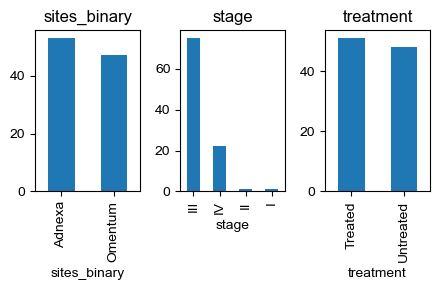

In [12]:
## Find untreated, adnexa samples

columns_of_interest = ['sites_binary', 'stage', 'treatment']
fig, axes = plt.subplots(1, len(columns_of_interest), figsize=(len(columns_of_interest) * 1.5, 3))
for i, column in enumerate(columns_of_interest):
    sample_metadata[column].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(column)
plt.tight_layout()

mask = (sample_metadata['sites_binary'] == 'Adnexa') & (sample_metadata['treatment'] == 'Untreated')
samples_of_interest = sample_metadata.index[mask].tolist()

all_adata = adata[adata.obs['samples'].isin(samples_of_interest)].copy()
all_adata.obs['cell.types.nolc'] = all_adata.obs['cell.types'].str.replace('_LC', '')

In [ ]:
# selected_samples = np.random.choice(all_adata.obs['samples'].unique(), size=10, replace=False)
# all_adata = all_adata[all_adata.obs['samples'].isin(selected_samples)].copy()

### Process data to create torch dataset

In [13]:
# Separate individual slides
adatas = []
for i in all_adata.obs['samples'].unique():
    temp = all_adata[all_adata.obs['samples'] == i].copy()
    if temp.shape[0] < 100:
        continue
    adatas.append(temp)
    adatas[-1].obs['global'] = 0

# normalize and log transformation
adatas = sf.prep_adatas(adatas, norm=True, log1p=True, scale=False, renorm=False)

# create torch dataset
dataset = sf.make_dataset(adatas, sparse_graph=True, regional_obs=['global'])

  0%|          | 0/27 [00:00<?, ?it/s]

Using ['global'] as regional annotations.


  0%|          | 0/27 [00:00<?, ?it/s]

In [14]:
print(*adata.obs['cell.types'].unique())

Malignant Fibroblast Monocyte TNK.cell Malignant_LC B.cell Endothelial_LC Endothelial Fibroblast_LC TNK.cell_LC B.cell_LC Monocyte_LC Mast.cell_LC Mast.cell


In [15]:
immune_types = ['TNK.cell', 'B.cell', 'Monocyte', 'Mast.cell']
fibroblast_types = ['Fibroblast']

In [16]:
cuda_dataset = None

load_data_into_gpu = True # if you run into OOM on GPU, set this to False
if device == 'cuda' and load_data_into_gpu:
    cuda_dataset = dataset.to('cuda')

In [17]:
n_heads = 25

sf.set_random_seed(0)
model = sf.Steamboat(adata.var_names.tolist(), n_heads=n_heads, n_scales=3)
model = model.to(device)

use_dataset = cuda_dataset
if use_dataset is None:
    use_dataset = dataset

model.load_state_dict(torch.load('../examples/saved_models/hgsc.pth', weights_only=True), strict=False)

# model.fit(cuda_dataset, entry_masking_rate=0.1, feature_masking_rate=0.1,
#           max_epoch=10000, 
#           loss_fun=torch.nn.MSELoss(reduction='sum'),
#           opt=torch.optim.Adam, opt_args=dict(lr=0.1), stop_eps=1e-3, report_per=200, stop_tol=200, device=device)

<All keys matched successfully>

In [18]:
sf.tools.calc_obs(adatas, dataset, model, get_recon=True)

  0%|          | 0/27 [00:00<?, ?it/s]

In [20]:
adatas[0].obs

,orig.ident,nCount_RNA,nFeature_RNA,samples,patients,sites_binary,cell.types,cell.subtypes,x,y,cell.types.nolc,global
SMI_T10_F001_c1017,SMI,848,357,SMI_T10_F001,HGSC1,Adnexa,Malignant,Malignant,1493.3500,3151.233,Malignant,0
SMI_T10_F001_c102,SMI,731,319,SMI_T10_F001,HGSC1,Adnexa,Malignant,Malignant,2623.2000,3607.450,Malignant,0
SMI_T10_F001_c1062,SMI,236,155,SMI_T10_F001,HGSC1,Adnexa,Malignant,Malignant,850.5670,3143.833,Malignant,0
SMI_T10_F001_c1064,SMI,609,300,SMI_T10_F001,HGSC1,Adnexa,Malignant,Malignant,3222.7300,3152.586,Malignant,0
SMI_T10_F001_c1075,SMI,310,174,SMI_T10_F001,HGSC1,Adnexa,Malignant,Malignant,78.0125,3179.012,Malignant,0
...,...,...,...,...,...,...,...,...,...,...,...,...
SMI_T10_F001_c7224,SMI,74,57,SMI_T10_F001,HGSC1,Adnexa,Malignant,Malignant,280.1400,337.710,Malignant,0
SMI_T10_F001_c250,SMI,67,51,SMI_T10_F001,HGSC1,Adnexa,Malignant,Malignant,1653.0700,3541.425,Malignant,0
SMI_T10_F001_c1268,SMI,83,55,SMI_T10_F001,HGSC1,Adnexa,B.cell,B.cell,2817.0000,3031.000,B.cell,0
SMI_T10_F001_c500,SMI,91,51,SMI_T10_F001,HGSC1,Adnexa,Fibroblast_LC,Fibroblast_LC,2288.7300,3389.050,Fibroblast,0


C:\Users\lshh\AppData\Local\Temp\ipykernel_69248\4258828269.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pd.crosstab(adata.obs['steamboat_spatial_domain'], adata.obs['cell.types.nolc']).to_csv(f"./saved_results/hgsc_fine_spatial_domain/hgsc_{adata.obs['samples'][0]}_steamboat_spatial_domain_crosstab.csv")
C:\Users\lshh\AppData\Local\Temp\ipykernel_69248\4258828269.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  adata.obs['steamboat_spatial_domain'].to_csv(f"./saved_results/hgsc_fine_spatial_domain/hgsc_{adata.obs['samples'][0]}_steamboat_spatial_domain.csv")
c:\Users\lshh\miniconda3\envs\py313_torch291_cud

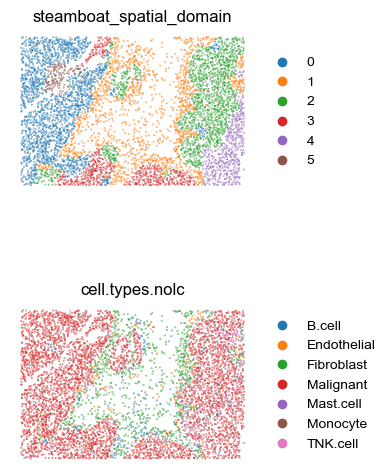

In [35]:
for i in range(len(adatas)):
    adata = adatas[i]
    if 'steamboat_spatial_domain_colors' in adata.uns:
        adata.uns.pop('steamboat_spatial_domain_colors')
    sf.tools.segment(adata, resolution=.7, key_added="steamboat_spatial_domain", n_prop=2)
    
    pd.crosstab(adata.obs['steamboat_spatial_domain'], adata.obs['cell.types.nolc']).to_csv(f"./saved_results/hgsc_fine_spatial_domain/hgsc_{adata.obs['samples'][0]}_steamboat_spatial_domain_crosstab.csv")
    adata.obs['steamboat_spatial_domain'].to_csv(f"./saved_results/hgsc_fine_spatial_domain/hgsc_{adata.obs['samples'][0]}_steamboat_spatial_domain.csv")
    
    sq.pl.spatial_scatter(adata, color=["steamboat_spatial_domain", "cell.types.nolc"], size=.1, shape=None, legend_loc='right margin', frameon=False, figsize=(3, 3), ncols=1)
    plt.savefig(f"./saved_results/hgsc_fine_spatial_domain/hgsc_{adata.obs['samples'][0]}_steamboat_spatial_domain.png", bbox_inches='tight')
    break

In [36]:
df = pd.crosstab(adatas[0].obs['steamboat_spatial_domain'], adatas[0].obs['cell.types.nolc'])
n = df.loc['0', ['B.cell', 'Mast.cell', 'Monocyte', 'TNK.cell']].sum()
N = n + df.loc['0', 'Malignant']
m = df.loc['1', ['B.cell', 'Mast.cell', 'Monocyte', 'TNK.cell']].sum()
M = m + df.loc['1', 'Malignant']

# proportion_test(N, n, M, m)
df / df.sum(axis=0)

cell.types.nolc,B.cell,Endothelial,Fibroblast,Malignant,Mast.cell,Monocyte,TNK.cell
steamboat_spatial_domain,,,,,,,
0,0.010989,0.075269,0.00750,0.458032,0.0,0.084507,0.024096
1,0.873626,0.908602,0.98125,0.016090,1.0,0.230047,0.310241
2,0.076923,0.005376,0.01000,0.262537,0.0,0.474178,0.518072
3,0.000000,0.010753,0.00125,0.141057,0.0,0.063380,0.045181
4,0.021978,0.000000,0.00000,0.095468,0.0,0.079812,0.093373
5,0.016484,0.000000,0.00000,0.026817,0.0,0.068075,0.009036


In [37]:
df

cell.types.nolc,B.cell,Endothelial,Fibroblast,Malignant,Mast.cell,Monocyte,TNK.cell
steamboat_spatial_domain,,,,,,,
0,2,14,6,1708,0,36,8
1,159,169,785,60,5,98,103
2,14,1,8,979,0,202,172
3,0,2,1,526,0,27,15
4,4,0,0,356,0,34,31
5,3,0,0,100,0,29,3
